### EDA - REGISTRO VENTAS FARMACIA ###

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("../data/raw/farmacia-datos.csv", sep=";", encoding="latin1")
df.head()

,Fecha,Tipo Mov.,Fac. Tipo,Fac. Suc.,Fac. Nun.,Fisc. Numero,Tipo Pago,Cant.,Precio,Producto,Sub. Total,Rubro,Cobertura,Ajustes,Desc. Adic.,Total. Cliente,IVA,Tasa Iva,Total Gravado,Total sin Gravar
0,01/01/25 01.13.46,F,B,0,379923,NaN,E,1,9344,ACTRON PEDIATRICO 4% susp.oral x 100 ml,9344,FARMACIA,0,0,0,9344,0,0,0,9344
1,01/01/25 01.59.21,F,B,0,379924,NaN,E,1,"8174,96",AMOXIDAL 500 mg comp.rec.x 21,"8174,96",FARMACIA,"3032,85",0,0,"5142,11",0,0,0,"8174,96"
2,01/01/25 02.01.59,F,B,0,379925,NaN,E,1,"8174,96",AMOXIDAL 500 mg comp.rec.x 21,"8174,96",FARMACIA,"5318,1",0,0,"2856,86",0,0,0,"8174,96"
3,01/01/25 02.04.14,F,B,0,379926,NaN,E,1,"8086,82",MUELITA FORTE GEL gel pomo x 10 g,"8086,82",FARMACIA,0,0,0,"8086,82",0,0,0,"8086,82"
4,01/01/25 02.08.35,F,B,0,379927,NaN,E,1,"26750,12",DIOXAFLEX B12 comp.x 20,"26750,12",FARMACIA,0,0,0,"26750,12",0,0,0,"26750,12"


In [3]:
df.info(), df.shape

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 117415 entries, 0 to 117414
Data columns (total 20 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Fecha             117415 non-null  object 
 1   Tipo Mov.         117415 non-null  object 
 2   Fac. Tipo         117415 non-null  object 
 3   Fac. Suc.         117415 non-null  int64  
 4   Fac. Nun.         117415 non-null  int64  
 5   Fisc. Numero      0 non-null       float64
 6   Tipo Pago         117415 non-null  object 
 7   Cant.             117415 non-null  int64  
 8   Precio            117415 non-null  object 
 9   Producto          117414 non-null  object 
 10  Sub. Total        117415 non-null  object 
 11  Rubro             117415 non-null  object 
 12  Cobertura         117415 non-null  object 
 13  Ajustes           117415 non-null  int64  
 14  Desc. Adic.       117415 non-null  object 
 15  Total. Cliente    117415 non-null  object 
 16  IVA               11

(None, (117415, 20))

In [4]:
df.columns

Index(['Fecha', 'Tipo Mov.', 'Fac. Tipo', 'Fac. Suc.', 'Fac. Nun.',
       'Fisc. Numero', 'Tipo Pago', 'Cant.', 'Precio', 'Producto',
       'Sub. Total', 'Rubro', 'Cobertura', 'Ajustes', 'Desc. Adic.',
       'Total. Cliente', 'IVA', 'Tasa Iva', 'Total Gravado',
       'Total sin Gravar'],
      dtype='object')

In [5]:
List_num = df.select_dtypes(include=['float64','int64']).columns.tolist()
List_num

['Fac. Suc.', 'Fac. Nun.', 'Fisc. Numero', 'Cant.', 'Ajustes', 'Tasa Iva']

In [ ]:
cols_float = ['Fac. Suc.', 'Fac. Nun.', 'Fisc. Numero', 'Cant.','Precio', 'Sub. Total', 'Cobertura', 'Ajustes','Desc. Adic.', 'Total. Cliente', 'IVA', 'Tasa Iva','Total Gravado', 'Total sin Gravar']

In [ ]:
df[cols_float] = (df[cols_float].astype(str).replace(r'\.', '', regex=True).replace(',', '.', regex=True).apply(pd.to_numeric, errors='coerce'))

In [ ]:
df[cols_float].dtypes

Fac. Suc.             int64
Fac. Nun.             int64
Fisc. Numero        float64
Cant.                 int64
Precio              float64
Sub. Total          float64
Cobertura           float64
Ajustes               int64
Desc. Adic.         float64
Total. Cliente      float64
IVA                 float64
Tasa Iva              int64
Total Gravado       float64
Total sin Gravar    float64
dtype: object

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 117415 entries, 0 to 117414
Data columns (total 20 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Fecha             117415 non-null  object 
 1   Tipo Mov.         117415 non-null  object 
 2   Fac. Tipo         117415 non-null  object 
 3   Fac. Suc.         117415 non-null  int64  
 4   Fac. Nun.         117415 non-null  int64  
 5   Fisc. Numero      0 non-null       float64
 6   Tipo Pago         117415 non-null  object 
 7   Cant.             117415 non-null  int64  
 8   Precio            117415 non-null  float64
 9   Producto          117414 non-null  object 
 10  Sub. Total        117415 non-null  float64
 11  Rubro             117415 non-null  object 
 12  Cobertura         117415 non-null  float64
 13  Ajustes           117415 non-null  int64  
 14  Desc. Adic.       117415 non-null  float64
 15  Total. Cliente    117415 non-null  float64
 16  IVA               11

In [10]:
df.duplicated().sum()

np.int64(121)

In [11]:
df.describe().T.round(2)

,count,mean,std,min,25%,50%,75%,max
Fac. Suc.,117415.0,0.00,0.00,0.00,0.0,0.00,0.00,0.00
Fac. Nun.,117415.0,417643.59,22420.16,379923.00,398031.0,416281.00,437618.50,455865.00
Fisc. Numero,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Cant.,117415.0,1.37,1.86,0.00,1.0,1.00,1.00,106.00
Precio,117415.0,16421.45,19078.33,0.00,5700.0,11269.23,21433.53,760983.88
Sub. Total,117415.0,17387.68,30548.13,0.00,5740.0,11281.07,21938.31,3377910.00
Cobertura,117415.0,7755.71,26465.17,-157953.92,0.0,0.00,9929.95,3217060.00
Ajustes,117415.0,0.00,0.00,0.00,0.0,0.00,0.00,0.00
Desc. Adic.,117415.0,76.55,1109.67,-31312.40,0.0,0.00,0.00,64474.40
Total. Cliente,117415.0,9555.42,13447.96,0.00,3500.0,6700.00,12211.67,2448000.00


In [12]:
df.isnull().sum()

Fecha                    0
Tipo Mov.                0
Fac. Tipo                0
Fac. Suc.                0
Fac. Nun.                0
Fisc. Numero        117415
Tipo Pago                0
Cant.                    0
Precio                   0
Producto                 1
Sub. Total               0
Rubro                    0
Cobertura                0
Ajustes                  0
Desc. Adic.              0
Total. Cliente           0
IVA                      0
Tasa Iva                 0
Total Gravado            0
Total sin Gravar         0
dtype: int64

In [13]:
df.drop(['Fisc. Numero'],axis=1,inplace=True)

In [14]:
df['Producto'] = df['Producto'].str.lower()

In [ ]:
df['Producto'].nunique()

7671

In [ ]:
df['Producto'].value_counts()

Producto
gen lp ibuprofeno blister 600 mg x 10      1926
gen lp omeprazol blister 20 mg x 15        1205
aspirina prevent comp.cub.enterica x 50    1150
tafirol 1g x 8 (unica)                      870
tafirol 1 g comp.ran.x 50                   699
                                           ... 
probiomax pvo. sob. x 15                      1
artrait 2.5 mg comp.x 20                      1
dutasinar 0.5 mg comp.x 30                    1
ensure advance frutilla lata x 400 g          1
cod liver oil cáps.x 60                       1
Name: count, Length: 7671, dtype: int64

In [ ]:
df['Producto'].str.contains('unica', case=False, na=False).sum()

np.int64(7449)

In [44]:
df['Producto'].str.contains('gen', case=False, na=False).sum()

np.int64(8619)

In [45]:
df['Producto'].str.contains('ibu', case=False, na=False).sum()

np.int64(5100)

In [ ]:
df[['Producto', 'Precio']].drop_duplicates().shape[0]

37731

In [ ]:
df['Producto'].value_counts().head(25)

Producto
gen lp ibuprofeno blister 600 mg x 10                          1926
gen lp omeprazol blister 20 mg x 15                            1205
aspirina prevent comp.cub.enterica x 50                        1150
tafirol 1g x 8 (unica)                                          870
tafirol 1 g comp.ran.x 50                                       699
osteodyn sol.oral x 2 ml                                        605
refenax gts.nasales x 25 ml                                     543
gen lp diclofenac blister 75 mg x 15                            530
gen lp diclofenac pridinol blister x 15                         488
acc lp gasa esteril no 5 caja 10 x 10                           473
corbis 5 mg comp.rec.x 30                                       471
tafirol plus rapida accion cáps.bl. x 8                         471
alikal (unica)                                                  451
t4 montpellier 75 75 mcg comp.x 50                              446
acc lp tela antialergica 3m de 2.5 x 9 

concepto por mes de ventas, logica de negocio mas EDA

In [22]:
df['Fecha']


0         01/01/25 01.13.46
1         01/01/25 01.59.21
2         01/01/25 02.01.59
3         01/01/25 02.04.14
4         01/01/25 02.08.35
                ...        
117410    23/12/25 10.23.06
117411    23/12/25 10.25.57
117412    23/12/25 10.34.31
117413    23/12/25 10.38.49
117414    23/12/25 10.53.40
Name: Fecha, Length: 117415, dtype: object

In [23]:
df['Fecha'] = pd.to_datetime(
    df['Fecha'],
    format='%d/%m/%y %H.%M.%S',
    errors='coerce'
)


In [24]:
df['Fecha'] = pd.to_datetime(df['Fecha'])


In [25]:
df['Mes'] = df['Fecha'].dt.to_period('M')


In [26]:
df['Fecha']

0        2025-01-01 01:13:46
1        2025-01-01 01:59:21
2        2025-01-01 02:01:59
3        2025-01-01 02:04:14
4        2025-01-01 02:08:35
                 ...        
117410   2025-12-23 10:23:06
117411   2025-12-23 10:25:57
117412   2025-12-23 10:34:31
117413   2025-12-23 10:38:49
117414   2025-12-23 10:53:40
Name: Fecha, Length: 117415, dtype: datetime64[ns]

In [27]:
df['Mes']

0         2025-01
1         2025-01
2         2025-01
3         2025-01
4         2025-01
           ...   
117410    2025-12
117411    2025-12
117412    2025-12
117413    2025-12
117414    2025-12
Name: Mes, Length: 117415, dtype: period[M]

In [28]:
ventas = (df.groupby(['Mes', 'Producto'])['Cant.'].sum().reset_index())

In [29]:
top_5_mensual = (ventas.sort_values(['Mes', 'Cant.'], ascending=[True, False]).groupby('Mes').head(5))

In [30]:
top_5_mensual

,Mes,Producto,Cant.
498,2025-01,buscapina compositum comp.rec.x 20,383
2587,2025-01,sertal compuesto comp.rec.x 20,260
1367,2025-01,gen lp ibuprofeno blister 600 mg x 10,210
1917,2025-01,migral 500 mg comp.x 100,210
1377,2025-01,gen lp omeprazol blister 20 mg x 15,163
3498,2025-02,buscapina compositum comp.rec.x 20,252
4324,2025-02,gen lp ibuprofeno blister 600 mg x 10,190
5326,2025-02,qura plus comp.rec.x 20,186
5518,2025-02,sertal compuesto comp.rec.x 20,182
4333,2025-02,gen lp omeprazol blister 20 mg x 15,152


In [31]:
ventas_mensuales = (df.groupby(['Mes', 'Producto'], as_index=False)['Cant.'].sum())

In [32]:
top_100_mensual = (ventas_mensuales.sort_values(['Mes', 'Cant.'], ascending=[True, False]).groupby('Mes').head(100))

In [33]:
top_100_mensual

,Mes,Producto,Cant.
498,2025-01,buscapina compositum comp.rec.x 20,383
2587,2025-01,sertal compuesto comp.rec.x 20,260
1367,2025-01,gen lp ibuprofeno blister 600 mg x 10,210
1917,2025-01,migral 500 mg comp.x 100,210
1377,2025-01,gen lp omeprazol blister 20 mg x 15,163
...,...,...,...
34709,2025-12,macril cr.x 20 g,15
35500,2025-12,tafirol comp. x 10,15
33099,2025-12,acc lp guantes latex par,14
33234,2025-12,alplax 0.50 mg comp.x 60,14


In [34]:
enero = df[df['Mes'] == '2025-01']

In [35]:
top_enero = top_100_mensual[top_100_mensual['Mes'] == '2025-01']

In [36]:
top_enero

,Mes,Producto,Cant.
498,2025-01,buscapina compositum comp.rec.x 20,383
2587,2025-01,sertal compuesto comp.rec.x 20,260
1367,2025-01,gen lp ibuprofeno blister 600 mg x 10,210
1917,2025-01,migral 500 mg comp.x 100,210
1377,2025-01,gen lp omeprazol blister 20 mg x 15,163
...,...,...,...
358,2025-01,bagohepat comp.rec.x 40,22
2716,2025-01,tafirol comp.x 30,22
36,2025-01,acc lp jeringa descart con aguja 3 cc 40/80,21
62,2025-01,accesorio carey (unica),21


In [37]:
import pandas as pd

# Asegurarte de que las columnas estén limpias
df['Producto'] = df['Producto'].str.strip().str.lower()
df['Mes'] = df['Fecha'].dt.to_period('M')  # columna Mes ya creada

# 1️⃣ Agrupar por Mes y Producto, sumar cantidad
ventas = (
    df.groupby(['Mes', 'Producto'], as_index=False)['Cant.'].sum()
)

# 2️⃣ Calcular ranking por mes
ventas['rank'] = ventas.groupby('Mes')['Cant.'].rank(
    method='first',  # en caso de empate, asigna orden según aparición
    ascending=False  # más ventas → rank 1
)

# 3️⃣ Filtrar top 100 por mes
top_100_por_mes = ventas[ventas['rank'] <= 100].sort_values(['Mes', 'rank'])

# 4️⃣ Reset index para limpiar el DataFrame
top_100_por_mes = top_100_por_mes.reset_index(drop=True)

# ✅ Mostrar ejemplo
print(top_100_por_mes.head(20))


        Mes                                       Producto  Cant.  rank
0   2025-01             buscapina compositum comp.rec.x 20    383   1.0
1   2025-01                 sertal compuesto comp.rec.x 20    260   2.0
2   2025-01          gen lp ibuprofeno blister 600 mg x 10    210   3.0
3   2025-01                       migral 500 mg comp.x 100    210   4.0
4   2025-01            gen lp omeprazol blister 20 mg x 15    163   5.0
5   2025-01                      tafirol 1 g comp.ran.x 24    156   6.0
6   2025-01                   mylanta extra comp.mast.x 24    155   7.0
7   2025-01                                 alikal (unica)    143   8.0
8   2025-01  ensure advance liquido frutilla bot. x 220 ml    120   9.0
9   2025-01                          bayaspirina comp.x 30    113  10.0
10  2025-01        aspirina prevent comp.cub.enterica x 50    112  11.0
11  2025-01                      tafirol 1 g comp.ran.x 80     91  12.0
12  2025-01                           tetralgin comp.x 100     8

<Figure size 1200x800 with 0 Axes>

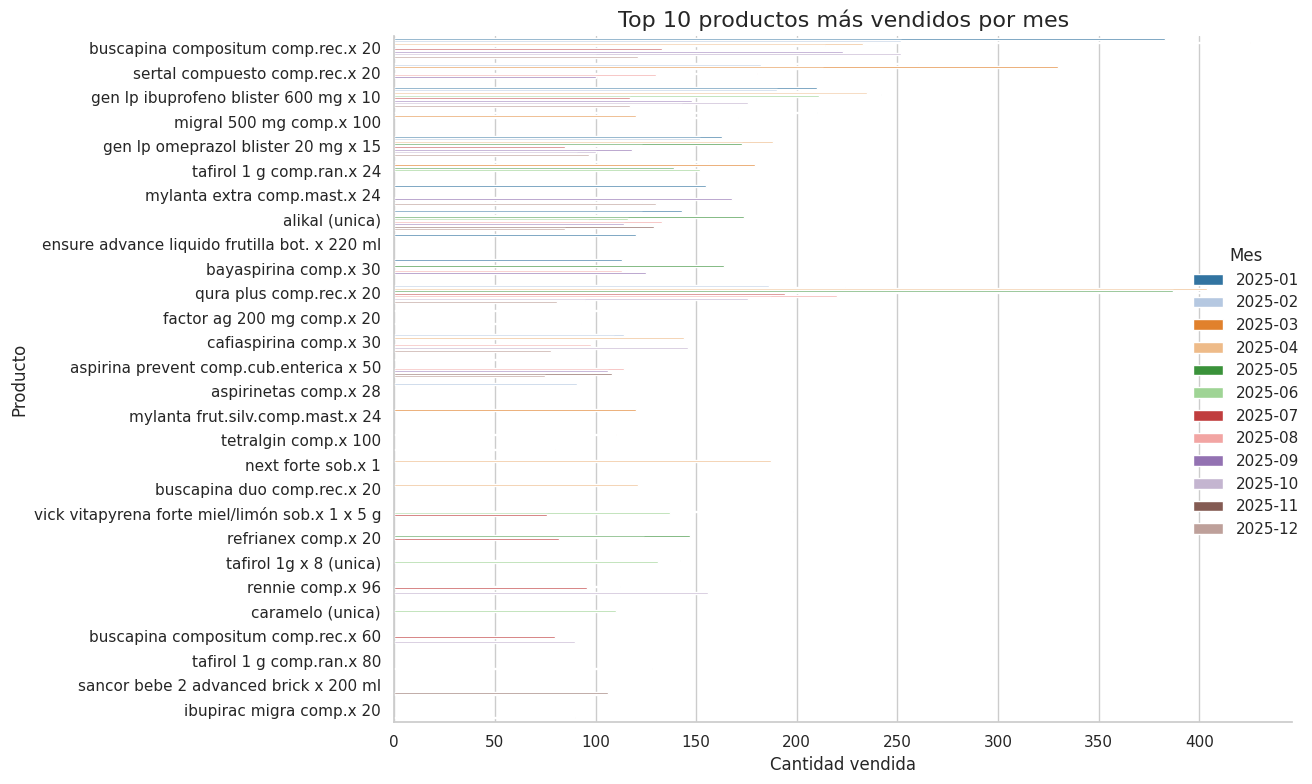

In [38]:
import matplotlib.pyplot as plt
import seaborn as sns

# Elegimos el top 10 de cada mes
top_10_por_mes = top_100_por_mes[top_100_por_mes['rank'] <= 10]

# Ajustes de estilo
sns.set(style="whitegrid")
plt.figure(figsize=(12, 8))

# Creamos gráfico de barras, separando por mes
g = sns.catplot(
    data=top_10_por_mes,
    x='Cant.', 
    y='Producto', 
    hue='Mes',
    kind='bar',
    height=8, 
    aspect=1.5,
    palette="tab20"
)

# Títulos y etiquetas
plt.title("Top 10 productos más vendidos por mes", fontsize=16)
plt.xlabel("Cantidad vendida", fontsize=12)
plt.ylabel("Producto", fontsize=12)
plt.tight_layout()

plt.show()


/tmp/ipykernel_2501/3632361701.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  g = sns.catplot(


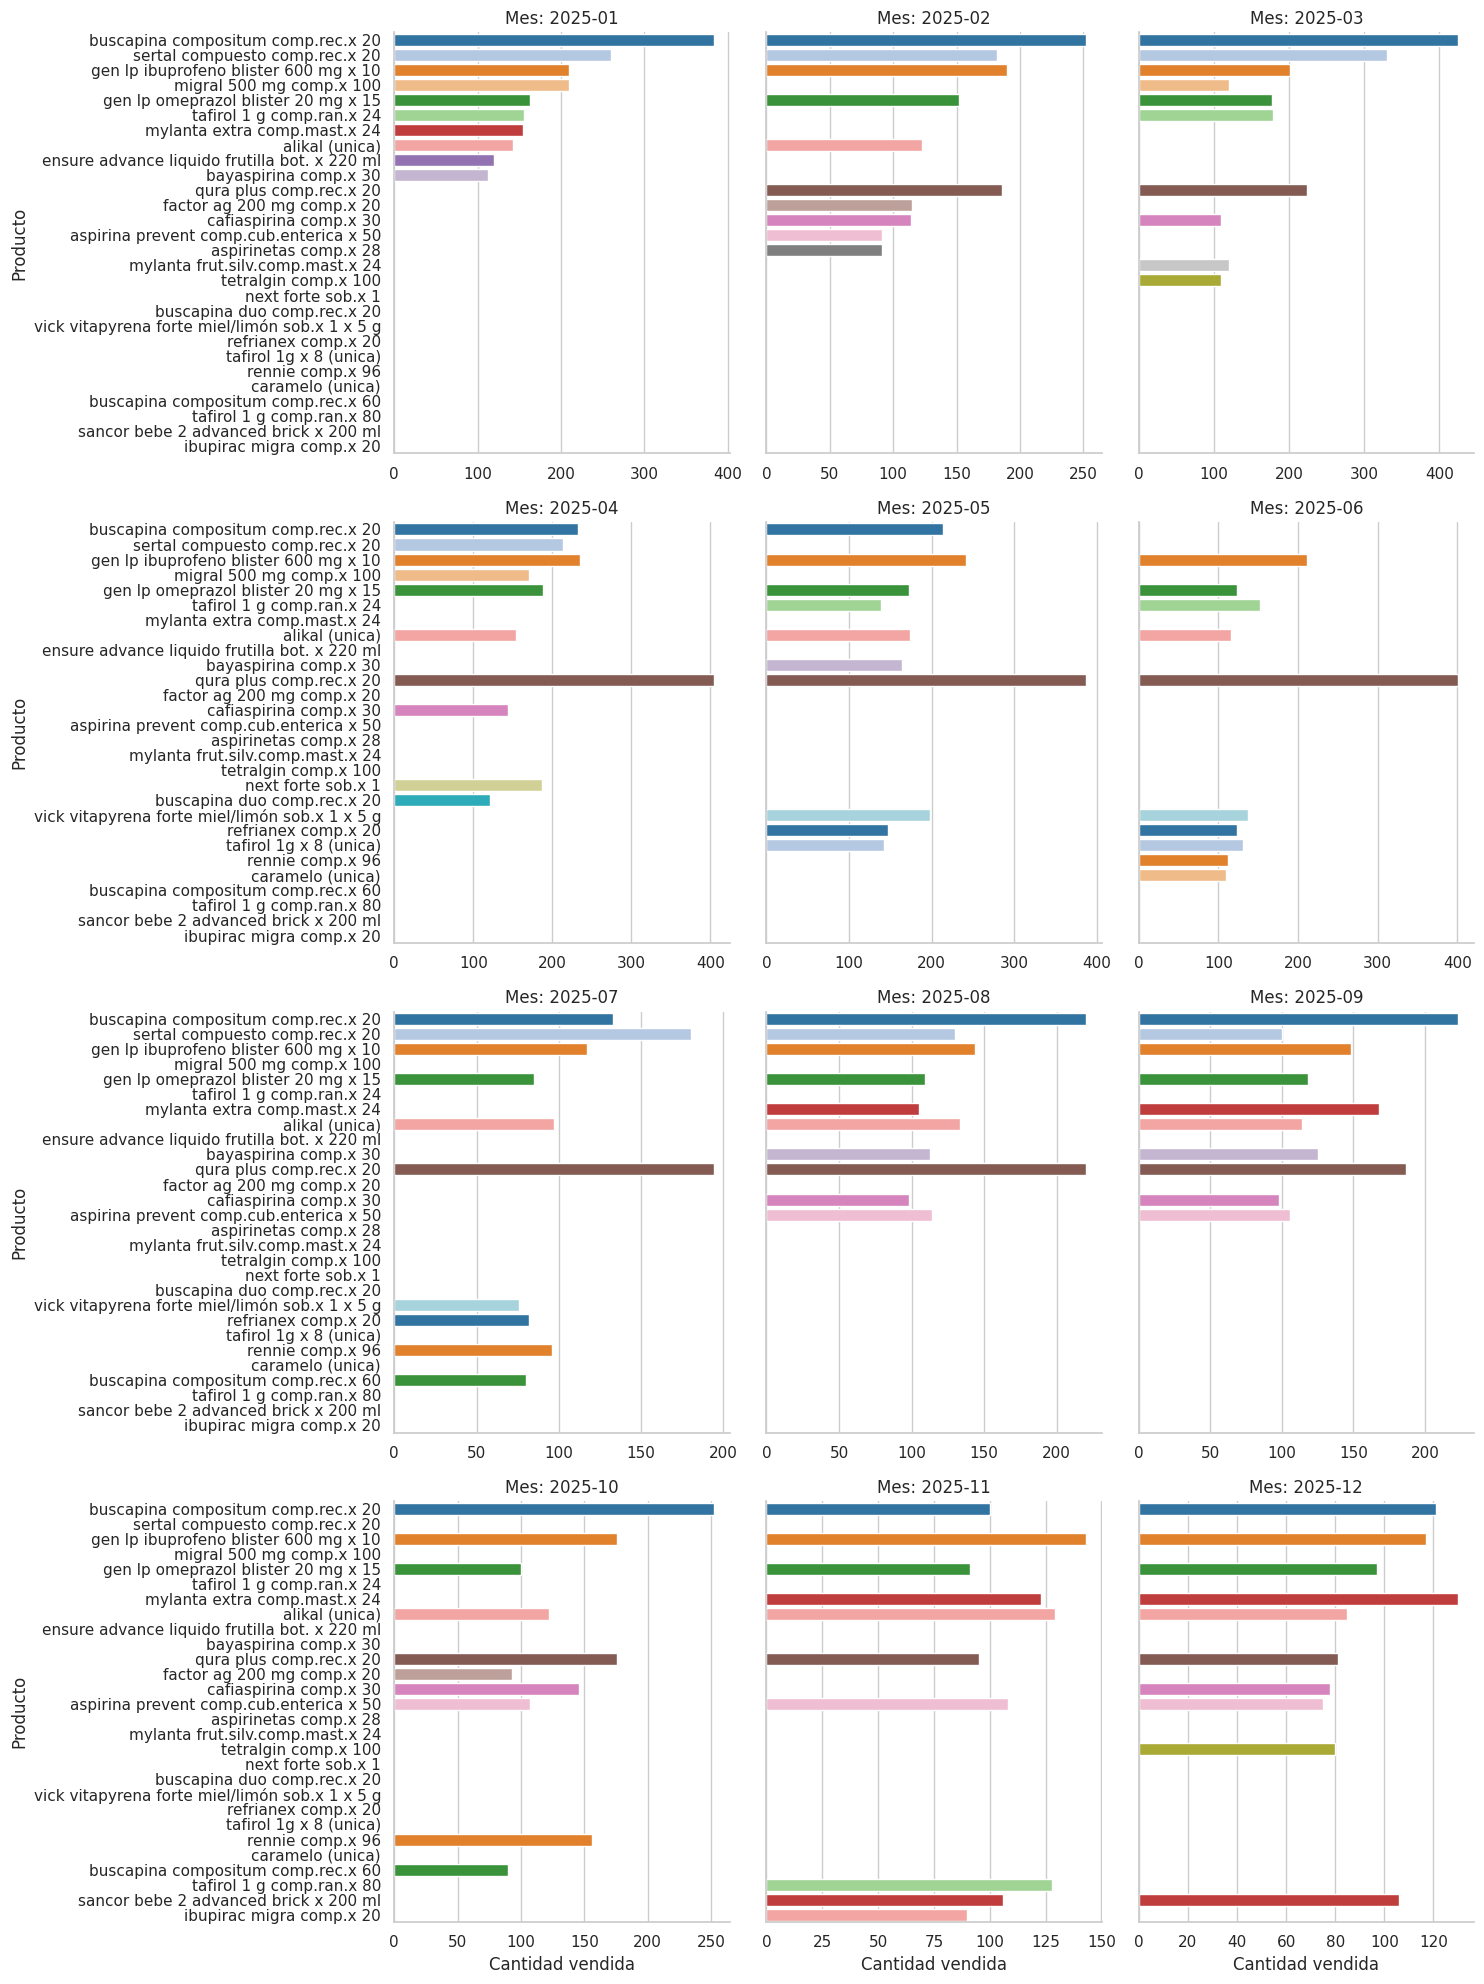

In [39]:
g = sns.catplot(
    data=top_10_por_mes,
    x='Cant.',
    y='Producto',
    col='Mes',
    kind='bar',
    col_wrap=3,
    height=5,
    sharex=False,
    palette="tab20"
)
g.set_titles("Mes: {col_name}")
g.set_axis_labels("Cantidad vendida", "Producto")
plt.tight_layout()
plt.show()


In [40]:
import matplotlib.pyplot as plt
import seaborn as sns

# Pivot table para heatmap
ventas_pivot = top_100_por_mes.pivot_table(
    index='Producto',
    columns='Mes',
    values='Cant.',
    aggfunc='sum',
    fill_value=0  # los productos que no se vendieron en un mes = 0
)

# Ordenar por ventas totales para destacar los más vendidos
ventas_pivot['Total'] = ventas_pivot.sum(axis=1)
ventas_pivot = ventas_pivot.sort_values('Total', ascending=False).drop('Total', axis=1)


/home/codespace/.local/lib/python3.12/site-packages/seaborn/utils.py:61: UserWarning: Glyph 9 (	) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/home/codespace/.local/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 9 (	) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


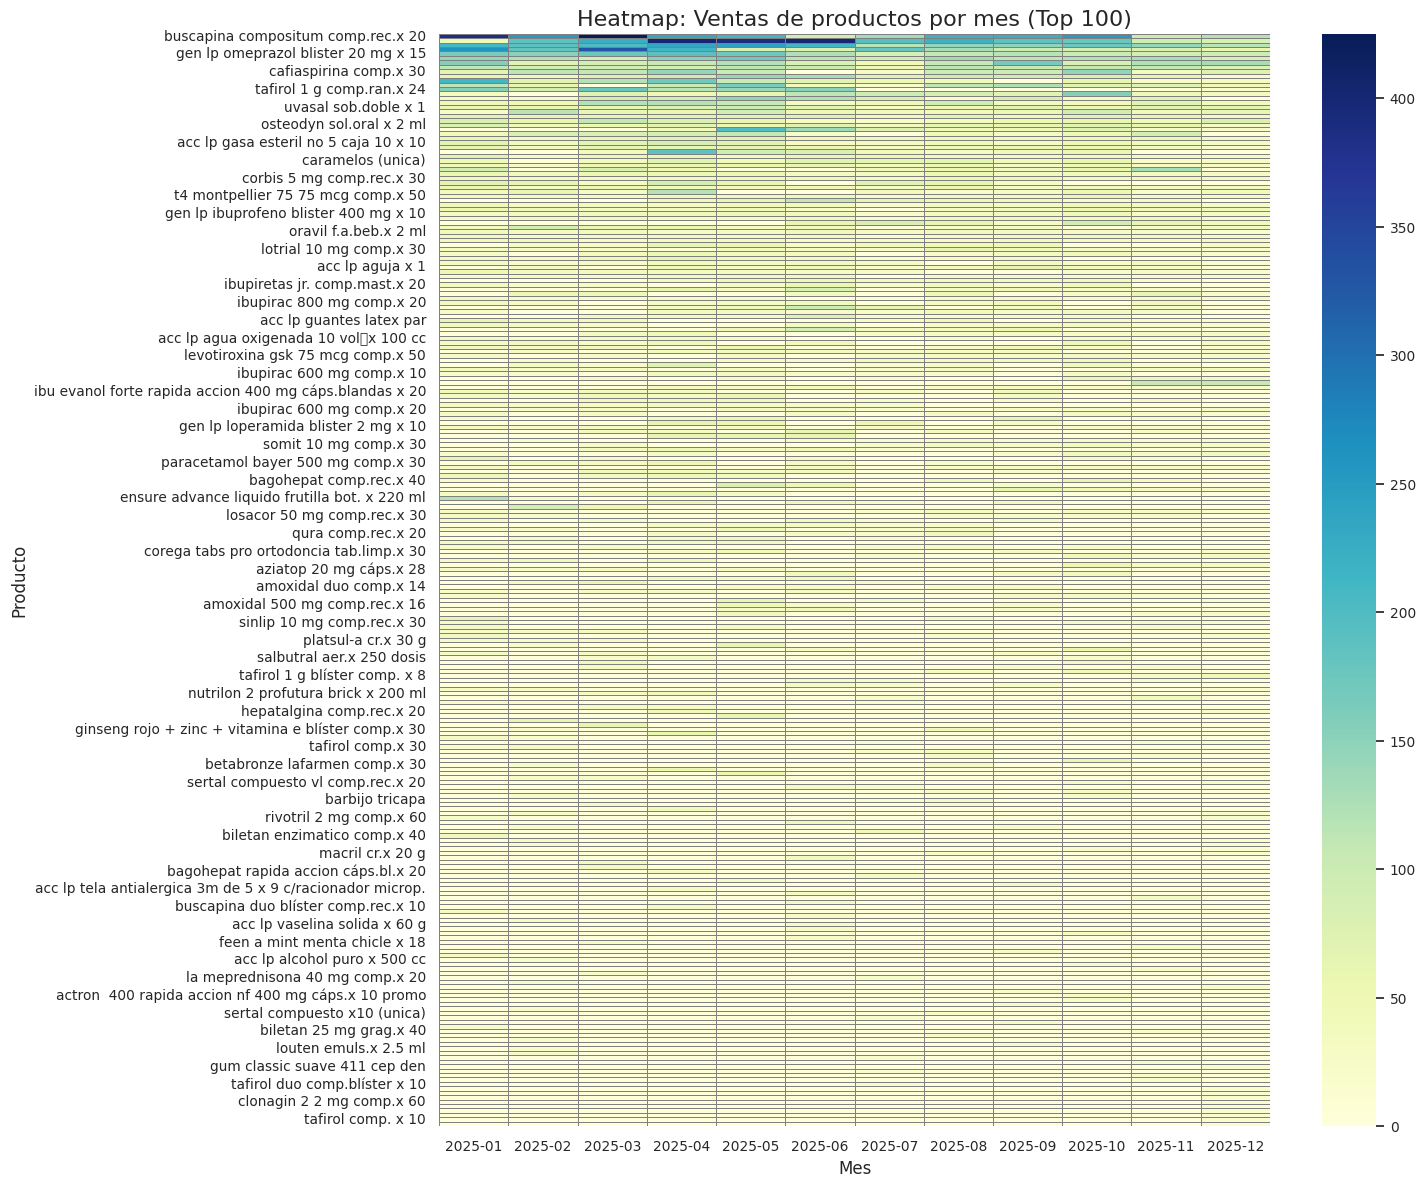

In [41]:
plt.figure(figsize=(15, 12))
sns.set(font_scale=0.9)

sns.heatmap(
    ventas_pivot,
    cmap="YlGnBu",   # color gradiente azul-verde
    linewidths=0.5,
    linecolor='gray'
)

plt.title("Heatmap: Ventas de productos por mes (Top 100)", fontsize=16)
plt.xlabel("Mes", fontsize=12)
plt.ylabel("Producto", fontsize=12)
plt.tight_layout()
plt.show()


In [42]:
# Pivot table de ventas
ventas_pivot = top_100_por_mes.pivot_table(
    index='Producto',
    columns='Mes',
    values='Cant.',
    aggfunc='sum',
    fill_value=0
)

# Calcular ventas totales por producto
ventas_pivot['Total'] = ventas_pivot.sum(axis=1)

# Seleccionar los top 30 productos
top30_productos = ventas_pivot.sort_values('Total', ascending=False).head(30).drop('Total', axis=1)


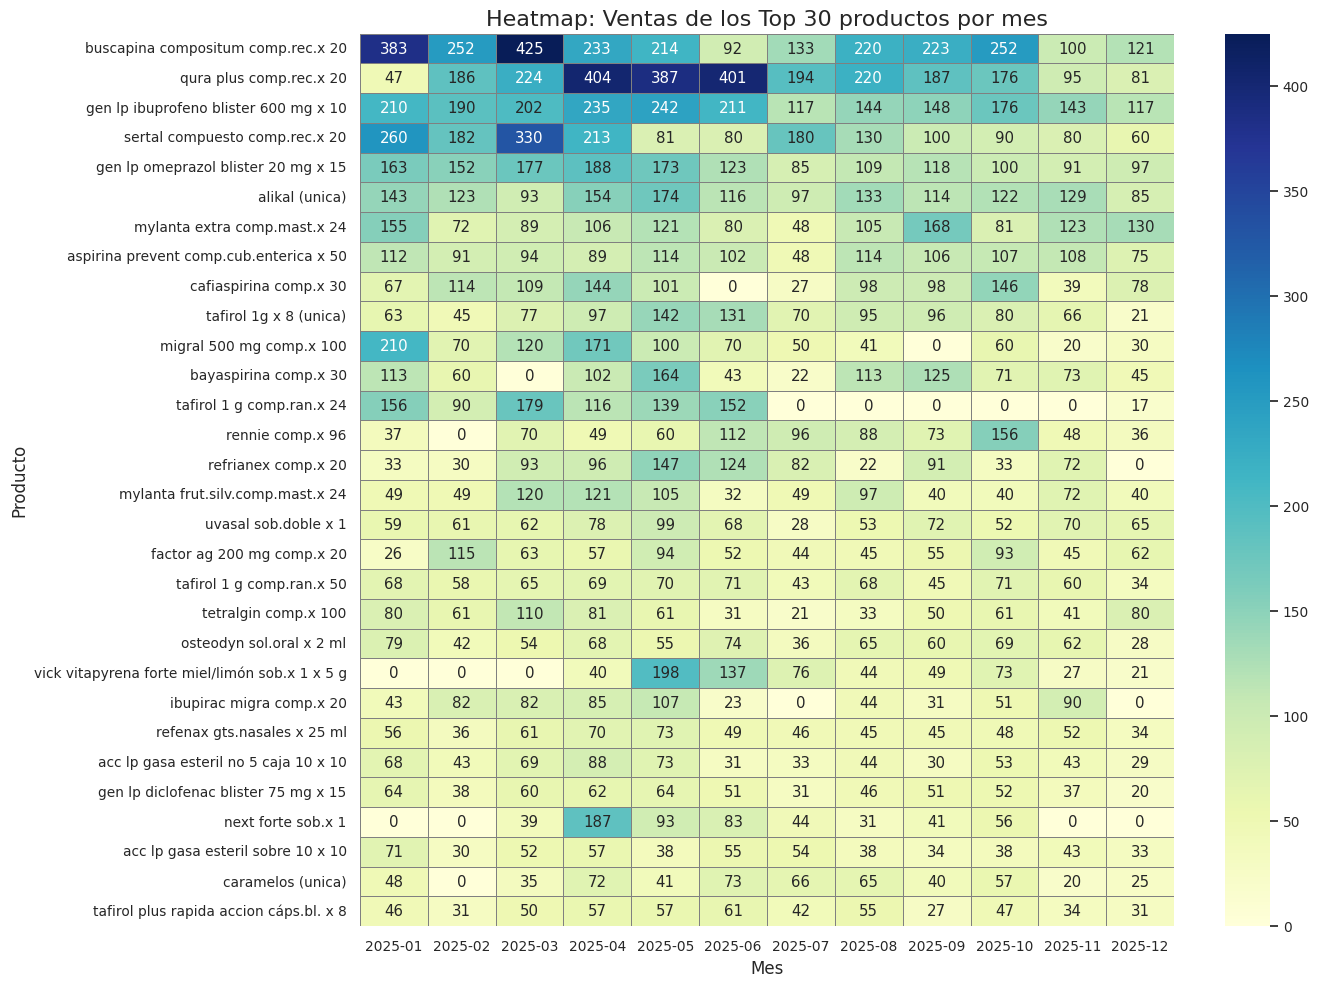

In [43]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(14, 10))
sns.set(font_scale=0.9)

sns.heatmap(
    top30_productos,
    cmap="YlGnBu",      # gradiente azul-verde
    linewidths=0.5,
    linecolor='gray',
    annot=True,          # opcional: muestra los números
    fmt=".0f"            # sin decimales
)

plt.title("Heatmap: Ventas de los Top 30 productos por mes", fontsize=16)
plt.xlabel("Mes", fontsize=12)
plt.ylabel("Producto", fontsize=12)
plt.tight_layout()
plt.show()
